In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/huhao05133/carseats/Carseats.csv


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("/kaggle/input/datasets/huhao05133/carseats/Carseats.csv")
df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [4]:
df["High"]=(df["Sales"]>8).astype(int)

In [5]:
X=df.drop(columns=["Sales","High"])
y=df["High"]
X=pd.get_dummies(X,drop_first=True)

In [6]:
# 70% entraînement / 30% test
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0)

In [7]:
#  normalisation
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [8]:
# test de plusieurs valeurs de k
for i in [1,3,5,7,9]:
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train_scaled,y_train)
    y_pred=model.predict(X_test_scaled)
    print("i=", i,"Accuracy=",accuracy_score(y_test,y_pred))

i= 1 Accuracy= 0.7583333333333333
i= 3 Accuracy= 0.7666666666666667
i= 5 Accuracy= 0.7666666666666667
i= 7 Accuracy= 0.75
i= 9 Accuracy= 0.7666666666666667


In [9]:
# préparation (on enlève la variable cible)
X_cluster=df.drop(columns=["Sales","High"])
# encodage
X_cluster=pd.get_dummies(X_cluster,drop_first=True)
# normalisation
scaler=StandardScaler()
X_cluster_scaled=scaler.fit_transform(X_cluster)

In [10]:
# modèle K-means avec 3 clusters
kmeans=KMeans(n_clusters=3,random_state=0)
clusters=kmeans.fit_predict(X_cluster_scaled)
df["Cluster"]=clusters
df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,High,Cluster
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1,1
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1,0
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,1,1
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0,1
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,0,2


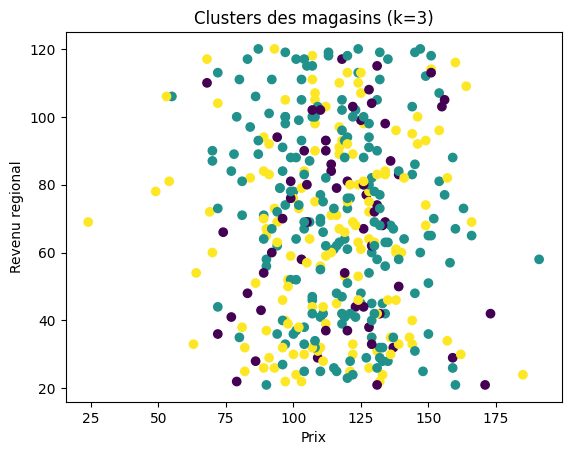

In [11]:
plt.scatter(df["Price"],df["Income"],c=df["Cluster"])
plt.xlabel("Prix")
plt.ylabel("Revenu regional")
plt.title("Clusters des magasins (k=3)")
plt.show()

In [12]:
kmeans=KMeans(n_clusters=2,random_state=0)
clusters=kmeans.fit_predict(X_cluster_scaled)
df["Cluster"]=clusters
df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,High,Cluster
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1,0
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1,0
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,1,1
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0,1
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,0,1


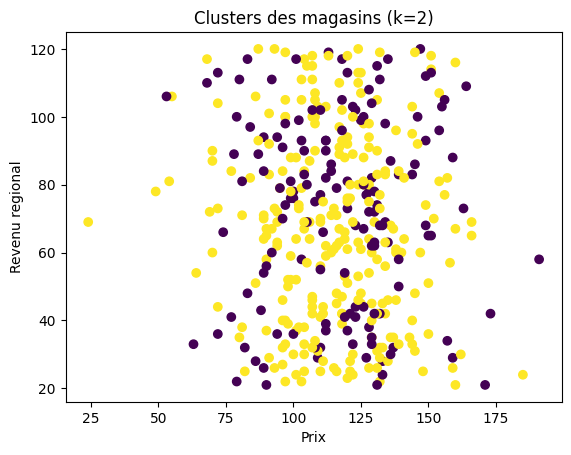

In [13]:
plt.scatter(df["Price"],df["Income"],c=df["Cluster"])
plt.xlabel("Prix")
plt.ylabel("Revenu regional")
plt.title("Clusters des magasins (k=2)")
plt.show()

In [14]:
kmeans=KMeans(n_clusters=4,random_state=0)
clusters=kmeans.fit_predict(X_cluster_scaled)
df["Cluster"]=clusters
df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,High,Cluster
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1,1
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1,3
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,1,0
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0,0
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,0,2


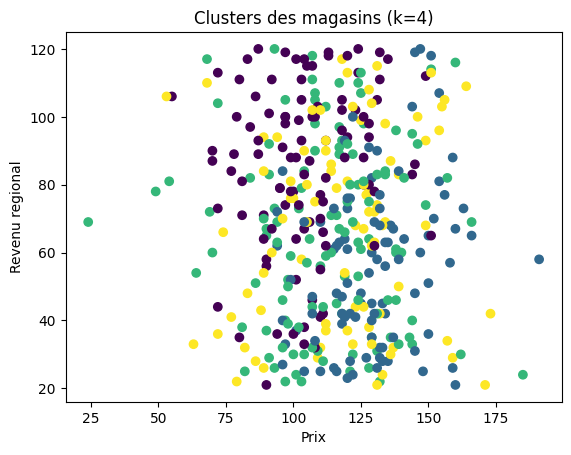

In [15]:
plt.scatter(df["Price"],df["Income"],c=df["Cluster"])
plt.xlabel("Prix")
plt.ylabel("Revenu regional")
plt.title("Clusters des magasins (k=4)")
plt.show()

# Ajout des algorithmes Random Forest et SVM

Cette partie est ajoutée sans modifier la première partie du notebook : KNN et KMeans restent inchangés.

Random Forest utilise les données normales `X_train` et `X_test`. SVM utilise les données normalisées `X_train_scaled` et `X_test_scaled`.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

## Random Forest

In [17]:
# création du modèle avec 100 arbres
rf_model=RandomForestClassifier(n_estimators=100,random_state=0)

rf_model.fit(X_train,y_train)

y_pred_rf=rf_model.predict(X_test)

acc_rf=accuracy_score(y_test,y_pred_rf)
# rapport détaillé
print("Accuracy Random Forest =",acc_rf)
print("Rapport de classification Random Forest")
print(classification_report(y_test,y_pred_rf))

print("Matrice de confusion Random Forest")
print(confusion_matrix(y_test,y_pred_rf))

Accuracy Random Forest = 0.8
Rapport de classification Random Forest
              precision    recall  f1-score   support

           0       0.79      0.88      0.83        67
           1       0.82      0.70      0.76        53

    accuracy                           0.80       120
   macro avg       0.80      0.79      0.79       120
weighted avg       0.80      0.80      0.80       120

Matrice de confusion Random Forest
[[59  8]
 [16 37]]


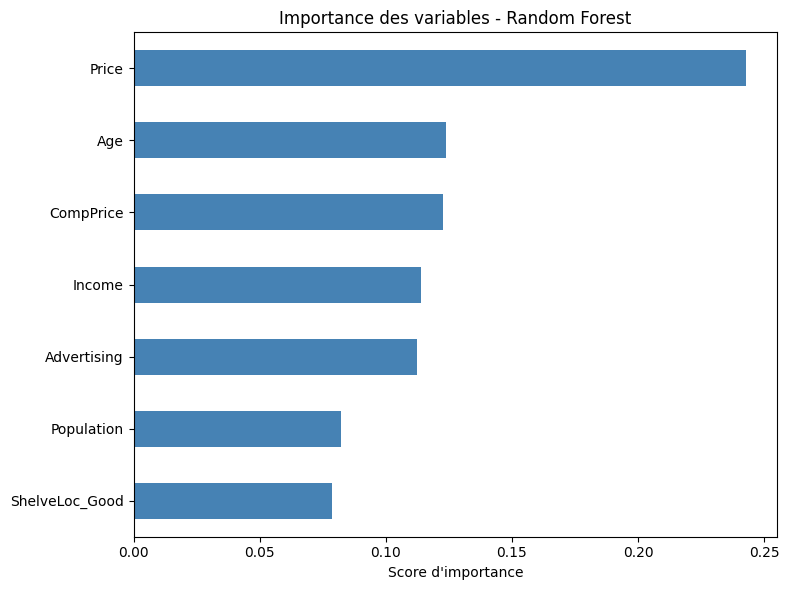

In [18]:
# Importance des variables - Top 7
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
# tri des variables les plus importantes
importances = importances.sort_values(ascending=False)  # décroissant pour prendre le top
importances_top7 = importances.head(7).sort_values(ascending=True)  # top 7, puis réordonner pour le graphe
# visualisation
plt.figure(figsize=(8, 6))
importances_top7.plot(kind="barh", color="steelblue")
plt.title("Importance des variables - Random Forest")
plt.xlabel("Score d'importance")
plt.tight_layout()
plt.show()

## SVM

In [19]:
# modèle SVM avec kernel RBF (non linéaire)
svm_model=SVC(kernel="rbf",random_state=0)

svm_model.fit(X_train_scaled,y_train)

y_pred_svm=svm_model.predict(X_test_scaled)

acc_svm=accuracy_score(y_test,y_pred_svm)
# résultats
print("Accuracy SVM =",acc_svm)

print("Rapport de classification SVM")
print(classification_report(y_test,y_pred_svm))

print("Matrice de confusion SVM")
print(confusion_matrix(y_test,y_pred_svm))

Accuracy SVM = 0.8416666666666667
Rapport de classification SVM
              precision    recall  f1-score   support

           0       0.83      0.90      0.86        67
           1       0.85      0.77      0.81        53

    accuracy                           0.84       120
   macro avg       0.84      0.83      0.84       120
weighted avg       0.84      0.84      0.84       120

Matrice de confusion SVM
[[60  7]
 [12 41]]


## Comparaison des algorithmes de classification

In [20]:
# meilleur score KNN
knn_results=[]

for i in [1,3,5,7,9]:
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train_scaled,y_train)
    y_pred_knn=model.predict(X_test_scaled)
    knn_results.append(accuracy_score(y_test,y_pred_knn))

best_knn=max(knn_results)
# comparaison des modèles
comparison=pd.DataFrame({
    "Algorithme":["KNN","Random Forest","SVM"],
    "Accuracy":[best_knn,acc_rf,acc_svm]
})

comparison

,Algorithme,Accuracy
0,KNN,0.766667
1,Random Forest,0.800000
2,SVM,0.841667
